1. Imports & Setup

We import all required libraries.

tensorflow.keras → to build and train the autoencoder

sklearn → for K-Means clustering, PCA, and evaluation

matplotlib and seaborn → for visualization  

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import seaborn as sns

2. Load & Preprocess Data

We load the MNIST dataset and prepare it for training.

Normalize pixel values to range [0, 1] for better learning

Flatten images from 28×28 → 784 so they can be used in dense layers

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step



3. Build Autoencoder

We construct the autoencoder model.

Encoder compresses the input from 784 → 32 dimensions (latent space)

Decoder reconstructs the image back to 784 dimensions

The model learns a compact representation of the data

In [3]:
latent_dim = 32

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(encoder_input)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu')(x)

# Decoder
x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(256, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

# Models
autoencoder = models.Model(encoder_input, decoder_output)
encoder = models.Model(encoder_input, latent)

4. Compile & Train

We train the autoencoder.

Loss function: MSE (Mean Squared Error) measures reconstruction quality

The model learns to reproduce input images from compressed representations

In [4]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0555 - val_loss: 0.0276
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0233 - val_loss: 0.0194
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0178 - val_loss: 0.0156
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0148 - val_loss: 0.0134
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0130 - val_loss: 0.0122
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0120 - val_loss: 0.0114
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0112 - val_loss: 0.0105
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0105 - val_loss: 0.0100
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0100 - val_loss: 0.0095
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0095 - val_loss: 0.0092
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0092 - val_loss: 0.0089
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2

5. Plot Training Loss

We visualize training performance.

Plot shows how reconstruction error decreases over time

Helps verify if the model is learning properly (no divergence/overfitting)

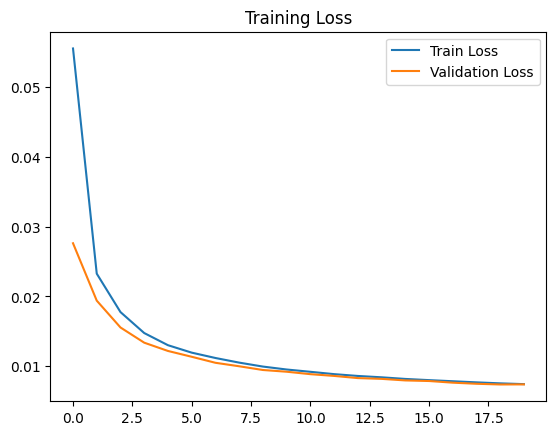

In [5]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

6. Extract Latent Features

We pass test data through the encoder.

Output is a low-dimensional representation (latent vectors)

These vectors are used for clustering

In [6]:
latent_vectors = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


7. K-Means Clustering

We apply clustering to latent features.

K-Means groups data into 10 clusters (digits 0–9)

Clustering is based on similarity in latent space

In [7]:
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(latent_vectors)

8. PCA Visualization (2D Projection)

We reduce dimensions for visualization.

PCA projects latent vectors to 2D space

Scatter plot shows how well clusters are separated

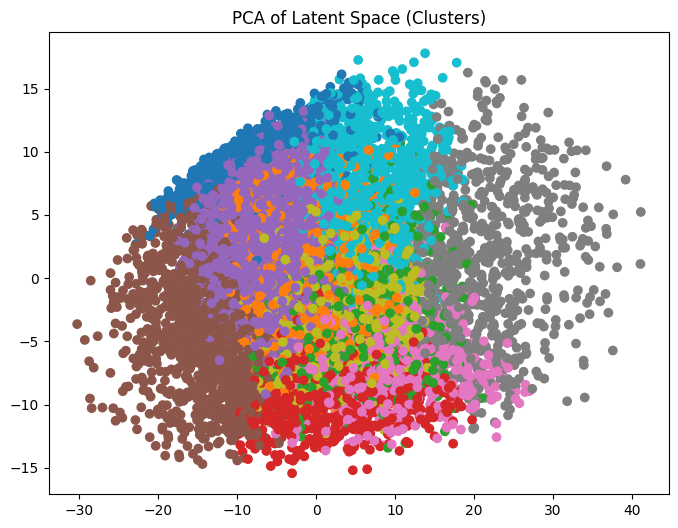

In [8]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=clusters, cmap='tab10')
plt.title("PCA of Latent Space (Clusters)")
plt.show()

9. Confusion Matrix

We evaluate clustering performance.

Compare predicted clusters with true labels

Shows how well clusters match actual digit classes

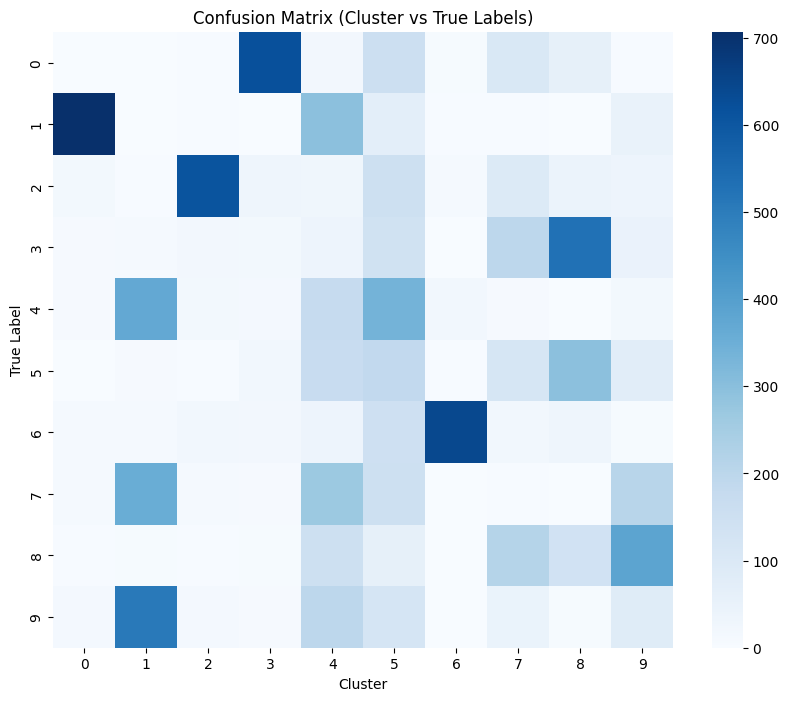

In [9]:
cm = confusion_matrix(y_test, clusters)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix (Cluster vs True Labels)")
plt.xlabel("Cluster")
plt.ylabel("True Label")
plt.show()

# Comparative Analysis

Supervised models such as Convolutional Neural Networks (CNNs) outperform unsupervised clustering approaches like autoencoder-based clustering in label accuracy because they directly optimize for classification objectives using labeled data. In supervised learning, the model receives explicit feedback through loss functions such as categorical cross-entropy, allowing it to learn discriminative features that maximize class separability.

In contrast, autoencoders are trained to reconstruct input data rather than to distinguish between classes. As a result, the latent space learned by an autoencoder captures general structural patterns in the data but does not necessarily align with class boundaries. When clustering methods like K-Means are applied to these latent representations, the algorithm groups data based on similarity rather than true semantic labels, which leads to lower accuracy.

Additionally, CNNs leverage spatial hierarchies in image data through convolutional layers, enabling them to extract more meaningful and localized features. Autoencoders, especially fully connected ones, may fail to preserve such spatial information. Therefore, while unsupervised methods are useful for representation learning and dimensionality reduction, supervised CNNs achieve superior performance in classification tasks due to their access to labeled data and task-specific optimization.